<div style="display: flex; align-items: center;">

  <!-- Logos -->
  <div style="white-space: nowrap;">
    <img 
      src="https://www.upc.edu/comunicacio/ca/identitat/descarrega-arxius-grafics/fitxers-marca-principal/upc-positiu-p3005.png" 
      width="300"
      style="vertical-align: middle;"
    >
    <img 
      src="https://www.hipotecalowcost.com/wp-content/uploads/2019/08/Logo-CaixaBank.png" 
      width="200"
      style="vertical-align: middle;"
    >
  </div>

  <!-- Texto -->
  <div style="margin-left: auto; margin-right: 100px; text-align: right;">
      <p style="margin: 0;"><b>CaixaBank · Advanced Analytics Program</b></p>
      <p style="margin: 0;"><b>Model Risk & Data Science Training</b></p>
      <p style="margin: 0;">Intelligence Data Science and Artificial Intelligence (IDEAI)</p>
  </div>

</div>

# Demo para auditores bancarios: Hugging Face + YOLOS/YOLO-like + BERT

## Objetivo

Este notebook muestra una demo sencilla para auditores de un banco combinando:

1. **Detección visual de objetos** con un modelo tipo YOLO/YOLOS desde Hugging Face.
2. **Clasificación de textos de ciberseguridad y fraude** usando embeddings de BERT.
3. **Priorización de riesgo** para apoyar una revisión manual de auditoría.

> Nota: en Hugging Face, dentro de `transformers`, una opción ligera para detección de objetos es **YOLOS** (`hustvl/yolos-tiny`). YOLOS no es exactamente YOLO clásico de Ultralytics, pero cumple una función parecida para demo: detección de objetos con cajas delimitadoras. Si se quiere YOLO clásico, normalmente se usa `ultralytics`, no `transformers`.


## 1. Instalación de librerías

Ejecuta esta celda si el entorno no tiene instaladas las dependencias.


In [ ]:
# Descomenta si necesitas instalar dependencias
# !pip install -U transformers torch torchvision pillow pandas numpy scikit-learn matplotlib seaborn

## 2. Imports y configuración

In [1]:
import os
import textwrap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image, ImageDraw, ImageFont

import torch
from transformers import pipeline
from transformers import AutoTokenizer, AutoModel

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

device = 0 if torch.cuda.is_available() else -1

print("GPU disponible:", torch.cuda.is_available())
print("Device pipeline:", device)

e:\TRABAJO\CURSOS\26WorkshopCaixabank\caixabank_formacion\.venv_tf\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


GPU disponible: False
Device pipeline: -1


# Parte A — Clasificación de textos con BERT

## Contexto bancario

Imagina que el banco recibe alertas internas, tickets, correos sospechosos o incidencias de operaciones.  
Queremos clasificar cada texto en categorías útiles para auditoría:

- `phishing`
- `fraude_transferencia`
- `ransomware`
- `abuso_interno`
- `operacion_normal`

Usaremos **BERT multilingüe** como extractor de características y después entrenaremos una regresión logística sencilla encima.


In [2]:
datos = [
    # PHISHING
    ("El cliente informa de un correo que imita al banco y pide validar credenciales en un enlace externo.", "phishing"),
    ("Se detecta campaña de SMS solicitando usuario, contraseña y token de doble factor.", "phishing"),
    ("Correo con dominio parecido al oficial solicita actualización urgente de datos bancarios.", "phishing"),
    ("Mensaje fraudulento redirige a una web falsa para capturar claves de acceso.", "phishing"),
    ("El email contiene adjunto sospechoso y pide confirmar cuenta por supuesta suspensión.", "phishing"),

    # FRAUDE TRANSFERENCIA
    ("Transferencia internacional de alto importe a beneficiario nuevo sin historial previo.", "fraude_transferencia"),
    ("Cambio reciente de IBAN seguido de orden de pago urgente a proveedor desconocido.", "fraude_transferencia"),
    ("Operación fuera del patrón habitual del cliente con importe elevado y país de riesgo.", "fraude_transferencia"),
    ("Varias transferencias fraccionadas justo por debajo del umbral de revisión manual.", "fraude_transferencia"),
    ("Pago aprobado tras modificación sospechosa de datos del beneficiario.", "fraude_transferencia"),

    # RANSOMWARE
    ("Equipo corporativo muestra archivos cifrados y nota de rescate solicitando criptomonedas.", "ransomware"),
    ("Servidor de ficheros inaccesible tras ejecución de binario desconocido.", "ransomware"),
    ("Múltiples equipos presentan extensión extraña en documentos y pérdida de acceso.", "ransomware"),
    ("Alerta EDR indica comportamiento de cifrado masivo en carpetas compartidas.", "ransomware"),
    ("Usuario reporta pantalla de rescate y bloqueo completo del sistema.", "ransomware"),

    # ABUSO INTERNO
    ("Empleado consulta expedientes de clientes sin relación con su cartera asignada.", "abuso_interno"),
    ("Acceso repetido a cuentas VIP fuera del horario laboral sin justificación.", "abuso_interno"),
    ("Descarga masiva de información sensible desde una cuenta interna.", "abuso_interno"),
    ("Usuario interno exporta listados de clientes antes de finalizar contrato.", "abuso_interno"),
    ("Patrón anómalo de consultas por parte de un empleado de oficina.", "abuso_interno"),

    # OPERACION NORMAL
    ("Cliente realiza transferencia habitual mensual a su cuenta de ahorro.", "operacion_normal"),
    ("Actualización rutinaria de datos de contacto verificada por canal seguro.", "operacion_normal"),
    ("Pago recurrente a proveedor registrado dentro del patrón esperado.", "operacion_normal"),
    ("Consulta de saldo desde dispositivo habitual y ubicación conocida.", "operacion_normal"),
    ("Revisión documental completada sin incidencias ni alertas adicionales.", "operacion_normal"),
]

df = pd.DataFrame(datos, columns=["texto", "categoria"])
df.head()

,texto,categoria
0,El cliente informa de un correo que imita al b...,phishing
1,"Se detecta campaña de SMS solicitando usuario,...",phishing
2,Correo con dominio parecido al oficial solicit...,phishing
3,Mensaje fraudulento redirige a una web falsa p...,phishing
4,El email contiene adjunto sospechoso y pide co...,phishing


In [3]:
print(df["categoria"].value_counts())

categoria
phishing                5
fraude_transferencia    5
ransomware              5
abuso_interno           5
operacion_normal        5
Name: count, dtype: int64


## 3. Cargar BERT y convertir textos en embeddings

Usamos `bert-base-multilingual-cased` para obtener una representación numérica del texto.

La idea didáctica para auditores es:

> El texto se transforma en vectores. Sobre esos vectores entrenamos un clasificador que aprende patrones asociados a phishing, fraude, ransomware, abuso interno u operación normal.


In [4]:
bert_model_name = "bert-base-multilingual-cased"

tokenizer = AutoTokenizer.from_pretrained(bert_model_name)
bert_model = AutoModel.from_pretrained(bert_model_name)

bert_model.eval()

print("Modelo BERT cargado:", bert_model_name)

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 7899.33it/s]
[transformers] BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Modelo BERT cargado: bert-base-multilingual-cased


In [5]:
def obtener_embedding_bert(textos, batch_size=8):
    embeddings = []

    for i in range(0, len(textos), batch_size):
        batch_textos = textos[i:i + batch_size]

        inputs = tokenizer(
            batch_textos,
            padding=True,
            truncation=True,
            max_length=128,
            return_tensors="pt"
        )

        with torch.no_grad():
            outputs = bert_model(**inputs)

        # CLS token: representación global aproximada del texto
        cls_embeddings = outputs.last_hidden_state[:, 0, :].cpu().numpy()
        embeddings.append(cls_embeddings)

    return np.vstack(embeddings)

X_bert = obtener_embedding_bert(df["texto"].tolist())
y = df["categoria"].values

print("Shape embeddings BERT:", X_bert.shape)

Shape embeddings BERT: (25, 768)


## 4. Entrenar clasificador encima de BERT

Como el dataset es pequeño y sintético, el objetivo no es obtener un modelo productivo, sino mostrar el flujo completo.


In [7]:
textos = df["texto"].astype(str).to_numpy()
y = np.asarray(y)

X_train, X_test, y_train, y_test, textos_train, textos_test = train_test_split(
    X_bert,
    y,
    textos,
    test_size=0.30,
    random_state=42,
    stratify=y
)

In [8]:
clf_bert = LogisticRegression(max_iter=2000, class_weight="balanced")
clf_bert.fit(X_train, y_train)

y_pred = clf_bert.predict(X_test)

print(classification_report(y_test, y_pred))

                      precision    recall  f1-score   support

       abuso_interno       0.00      0.00      0.00         2
fraude_transferencia       0.50      1.00      0.67         1
    operacion_normal       0.25      0.50      0.33         2
            phishing       1.00      0.50      0.67         2
          ransomware       0.00      0.00      0.00         1

            accuracy                           0.38         8
           macro avg       0.35      0.40      0.33         8
        weighted avg       0.38      0.38      0.33         8



e:\TRABAJO\CURSOS\26WorkshopCaixabank\caixabank_formacion\.venv_tf\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
e:\TRABAJO\CURSOS\26WorkshopCaixabank\caixabank_formacion\.venv_tf\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
e:\TRABAJO\CURSOS\26WorkshopCaixabank\caixabank_formacion\.venv_tf\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to co

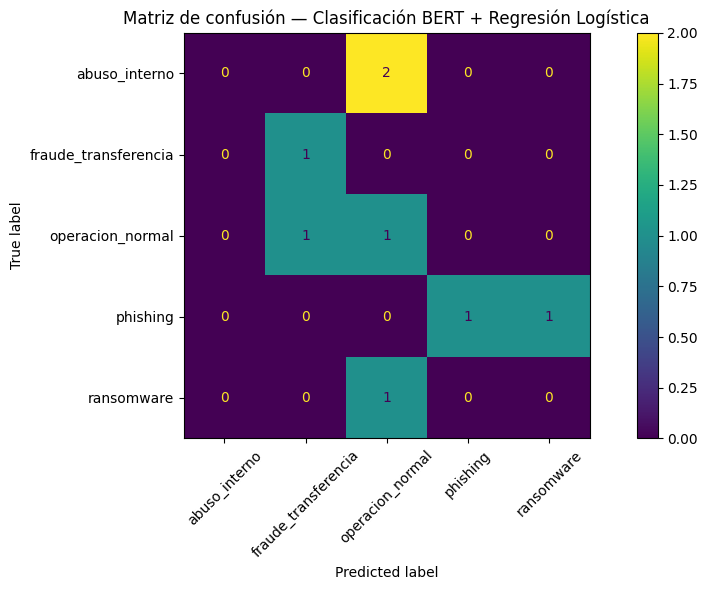

In [9]:
cm = confusion_matrix(y_test, y_pred, labels=clf_bert.classes_)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=clf_bert.classes_
)

fig, ax = plt.subplots(figsize=(10, 6))
disp.plot(ax=ax, xticks_rotation=45)
plt.title("Matriz de confusión — Clasificación BERT + Regresión Logística")
plt.tight_layout()
plt.show()

## 5. Inferencia sobre nuevas alertas

Creamos una función para que un auditor introduzca una descripción y el modelo devuelva una categoría probable.


In [10]:
def clasificar_alerta(texto):
    emb = obtener_embedding_bert([texto])
    pred = clf_bert.predict(emb)[0]
    proba = clf_bert.predict_proba(emb)[0]

    ranking = pd.DataFrame({
        "categoria": clf_bert.classes_,
        "probabilidad": proba
    }).sort_values("probabilidad", ascending=False)

    return pred, ranking

casos_nuevos = [
    "Correo urgente pide introducir claves de banca online en una página externa.",
    "Empleado descarga miles de registros de clientes durante la noche.",
    "Transferencia elevada a un beneficiario creado hace menos de una hora.",
    "Pago mensual habitual de nóminas a empleados registrados.",
    "Servidor compartido presenta archivos cifrados y mensaje de rescate."
]

for caso in casos_nuevos:
    pred, ranking = clasificar_alerta(caso)
    print("=" * 100)
    print("Texto:", caso)
    print("Predicción:", pred)
    display(ranking)

Texto: Correo urgente pide introducir claves de banca online en una página externa.
Predicción: phishing


,categoria,probabilidad
3,phishing,0.494297
1,fraude_transferencia,0.159689
0,abuso_interno,0.144444
4,ransomware,0.107930
2,operacion_normal,0.093639


Texto: Empleado descarga miles de registros de clientes durante la noche.
Predicción: abuso_interno


,categoria,probabilidad
0,abuso_interno,0.351054
4,ransomware,0.304242
3,phishing,0.174432
2,operacion_normal,0.089483
1,fraude_transferencia,0.080789


Texto: Transferencia elevada a un beneficiario creado hace menos de una hora.
Predicción: fraude_transferencia


,categoria,probabilidad
1,fraude_transferencia,0.433886
2,operacion_normal,0.270930
0,abuso_interno,0.187408
3,phishing,0.067833
4,ransomware,0.039943


Texto: Pago mensual habitual de nóminas a empleados registrados.
Predicción: fraude_transferencia


,categoria,probabilidad
1,fraude_transferencia,0.463098
2,operacion_normal,0.247595
0,abuso_interno,0.147689
3,phishing,0.090190
4,ransomware,0.051428


Texto: Servidor compartido presenta archivos cifrados y mensaje de rescate.
Predicción: ransomware


,categoria,probabilidad
4,ransomware,0.737609
2,operacion_normal,0.102733
0,abuso_interno,0.082622
3,phishing,0.058607
1,fraude_transferencia,0.018429


## 6. Tabla de priorización para auditoría

In [11]:
mapa_riesgo = {
    "ransomware": "ALTO",
    "phishing": "ALTO",
    "fraude_transferencia": "ALTO",
    "abuso_interno": "MEDIO-ALTO",
    "operacion_normal": "BAJO"
}

resultados = []

for caso in casos_nuevos:
    pred, ranking = clasificar_alerta(caso)
    confianza = ranking.iloc[0]["probabilidad"]

    resultados.append({
        "alerta": caso,
        "categoria_predicha": pred,
        "riesgo_auditoria": mapa_riesgo[pred],
        "confianza_modelo": round(float(confianza), 4),
        "accion_recomendada": "Revisión manual prioritaria" if mapa_riesgo[pred] in ["ALTO", "MEDIO-ALTO"] else "Muestreo o revisión rutinaria"
    })

df_resultados = pd.DataFrame(resultados)
df_resultados

,alerta,categoria_predicha,riesgo_auditoria,confianza_modelo,accion_recomendada
0,Correo urgente pide introducir claves de banca...,phishing,ALTO,0.4943,Revisión manual prioritaria
1,Empleado descarga miles de registros de client...,abuso_interno,MEDIO-ALTO,0.3511,Revisión manual prioritaria
2,Transferencia elevada a un beneficiario creado...,fraude_transferencia,ALTO,0.4339,Revisión manual prioritaria
3,Pago mensual habitual de nóminas a empleados r...,fraude_transferencia,ALTO,0.4631,Revisión manual prioritaria
4,Servidor compartido presenta archivos cifrados...,ransomware,ALTO,0.7376,Revisión manual prioritaria


# Parte B — Detección visual con modelo tipo YOLO/YOLOS

## Contexto bancario

En auditoría bancaria, la visión artificial puede servir para:

- detectar elementos en capturas de pantalla,
- revisar documentos escaneados,
- localizar objetos o zonas de interés,
- apoyar controles sobre documentación adjunta.

Para una demo rápida usaremos un modelo de Hugging Face para `object-detection`.

Modelo propuesto:

```text
hustvl/yolos-tiny
```

Es ligero y funciona mediante la API de `pipeline`.


In [12]:
object_detector = pipeline(
    task="object-detection",
    model="hustvl/yolos-tiny",
    device=device
)

print("Detector visual cargado correctamente.")

Loading weights: 100%|██████████| 211/211 [00:00<00:00, 25115.59it/s]


Detector visual cargado correctamente.


## 7. Crear una imagen sintética de ejemplo

Esta imagen no pretende ser realista como una captura bancaria real. Sirve para que el notebook sea ejecutable sin datos confidenciales.

Para una demo más potente, cambia `image_path` por una imagen real de prueba no sensible.


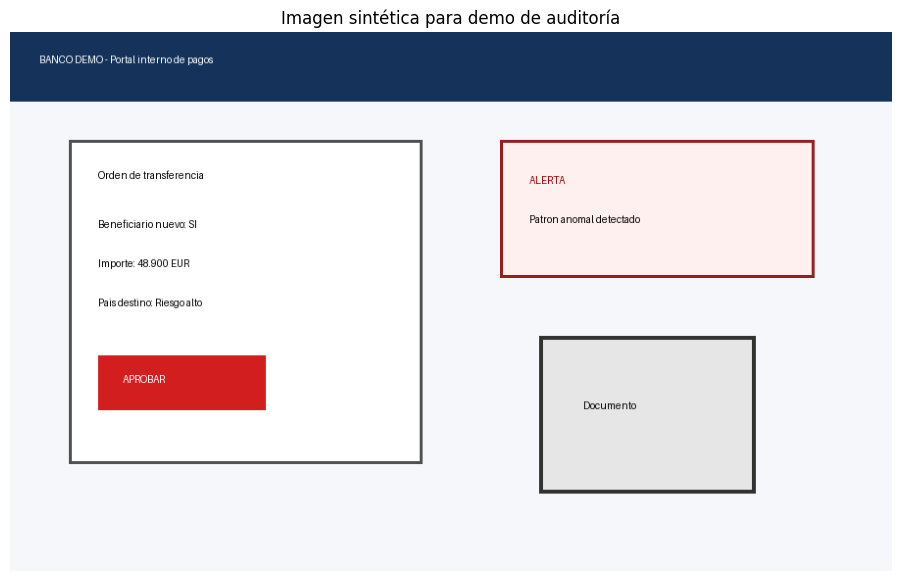

In [13]:
def crear_imagen_demo_bancaria(path="demo_auditoria_bancaria.png"):
    img = Image.new("RGB", (900, 550), color=(245, 247, 250))
    draw = ImageDraw.Draw(img)

    # Cabecera
    draw.rectangle([0, 0, 900, 70], fill=(20, 50, 90))
    draw.text((30, 22), "BANCO DEMO - Portal interno de pagos", fill="white")

    # Panel operación
    draw.rectangle([60, 110, 420, 440], outline=(80, 80, 80), width=3, fill=(255, 255, 255))
    draw.text((90, 140), "Orden de transferencia", fill=(0, 0, 0))
    draw.text((90, 190), "Beneficiario nuevo: SI", fill=(0, 0, 0))
    draw.text((90, 230), "Importe: 48.900 EUR", fill=(0, 0, 0))
    draw.text((90, 270), "Pais destino: Riesgo alto", fill=(0, 0, 0))
    draw.rectangle([90, 330, 260, 385], fill=(210, 30, 30))
    draw.text((115, 348), "APROBAR", fill="white")

    # Panel alerta
    draw.rectangle([500, 110, 820, 250], outline=(150, 30, 30), width=3, fill=(255, 240, 240))
    draw.text((530, 145), "ALERTA", fill=(150, 0, 0))
    draw.text((530, 185), "Patron anomal detectado", fill=(0, 0, 0))

    # Simulación de documento
    draw.rectangle([540, 310, 760, 470], outline=(50, 50, 50), width=4, fill=(230, 230, 230))
    draw.text((585, 375), "Documento", fill=(0, 0, 0))

    img.save(path)
    return path

image_path = crear_imagen_demo_bancaria()
image = Image.open(image_path)

plt.figure(figsize=(12, 7))
plt.imshow(image)
plt.axis("off")
plt.title("Imagen sintética para demo de auditoría")
plt.show()

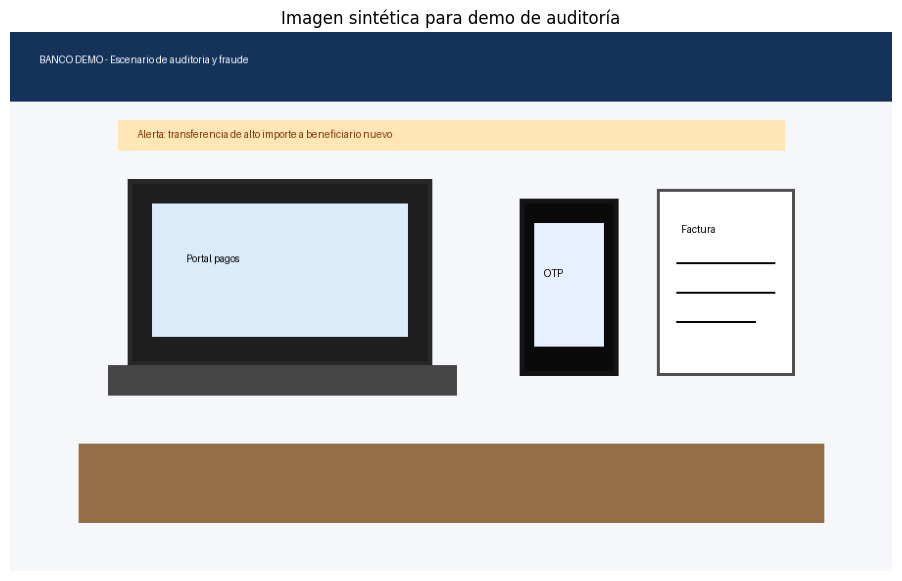

In [16]:
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt

def crear_imagen_demo_bancaria(path="demo_auditoria_bancaria.png"):
    img = Image.new("RGB", (900, 550), color=(245, 247, 250))
    draw = ImageDraw.Draw(img)

    # Cabecera
    draw.rectangle([0, 0, 900, 70], fill=(20, 50, 90))
    draw.text((30, 22), "BANCO DEMO - Escenario de auditoria y fraude", fill="white")

    # Mesa
    draw.rectangle([70, 420, 830, 500], fill=(150, 110, 70))

    # Portátil aproximado
    draw.rectangle([120, 150, 430, 340], outline=(40, 40, 40), width=5, fill=(30, 30, 30))
    draw.rectangle([145, 175, 405, 310], fill=(220, 235, 250))
    draw.text((180, 225), "Portal pagos", fill=(0, 0, 0))
    draw.rectangle([100, 340, 455, 370], fill=(70, 70, 70))

    # Teléfono móvil
    draw.rectangle([520, 170, 620, 350], outline=(20, 20, 20), width=5, fill=(10, 10, 10))
    draw.rectangle([535, 195, 605, 320], fill=(230, 240, 255))
    draw.text((545, 240), "OTP", fill=(0, 0, 0))

    # Documento / hoja
    draw.rectangle([660, 160, 800, 350], outline=(80, 80, 80), width=3, fill=(255, 255, 255))
    draw.text((685, 195), "Factura", fill=(0, 0, 0))
    draw.line([680, 235, 780, 235], fill=(0, 0, 0), width=2)
    draw.line([680, 265, 780, 265], fill=(0, 0, 0), width=2)
    draw.line([680, 295, 760, 295], fill=(0, 0, 0), width=2)

    # Alerta visual
    draw.rectangle([110, 90, 790, 120], fill=(255, 230, 180))
    draw.text((130, 98), "Alerta: transferencia de alto importe a beneficiario nuevo", fill=(120, 50, 0))

    img.save(path)
    return path

image_path = crear_imagen_demo_bancaria()
image = Image.open(image_path)

plt.figure(figsize=(12, 7))
plt.imshow(image)
plt.axis("off")
plt.title("Imagen sintética para demo de auditoría")
plt.show()

## 8. Ejecutar detección visual

En imágenes reales, el detector puede localizar objetos conocidos por el modelo.  
En una captura bancaria sintética puede no detectar todo, porque el modelo base suele estar entrenado en objetos generales tipo COCO, no en botones bancarios o campos de formulario.

Para un caso bancario real, habría que hacer fine-tuning con:

- capturas etiquetadas,
- documentos internos anonimizados,
- clases específicas: `boton_aprobar`, `iban`, `importe`, `firma`, `qr`, `sello`, `campo_beneficiario`, etc.


In [14]:
detecciones = object_detector(image)

detecciones[:5]

[]

In [18]:
from PIL import Image
import requests
from io import BytesIO

url = "https://img.magnific.com/foto-gratis/smartphone-planta-cerca-calculadora-portatil_23-2147768846.jpg?semt=ais_hybrid&w=740&q=80"
image = Image.open(BytesIO(requests.get(url).content)).convert("RGB")

detecciones = object_detector(image, threshold=0.1)
detecciones[:10]

[{'score': 0.611940324306488,
  'label': 'laptop',
  'box': {'xmin': 222, 'ymin': 1, 'xmax': 740, 'ymax': 332}},
 {'score': 0.12783168256282806,
  'label': 'cell phone',
  'box': {'xmin': 2, 'ymin': 0, 'xmax': 212, 'ymax': 179}},
 {'score': 0.9935072660446167,
  'label': 'cell phone',
  'box': {'xmin': 136, 'ymin': 228, 'xmax': 245, 'ymax': 451}},
 {'score': 0.1154806837439537,
  'label': 'dining table',
  'box': {'xmin': -1, 'ymin': 0, 'xmax': 737, 'ymax': 490}}]

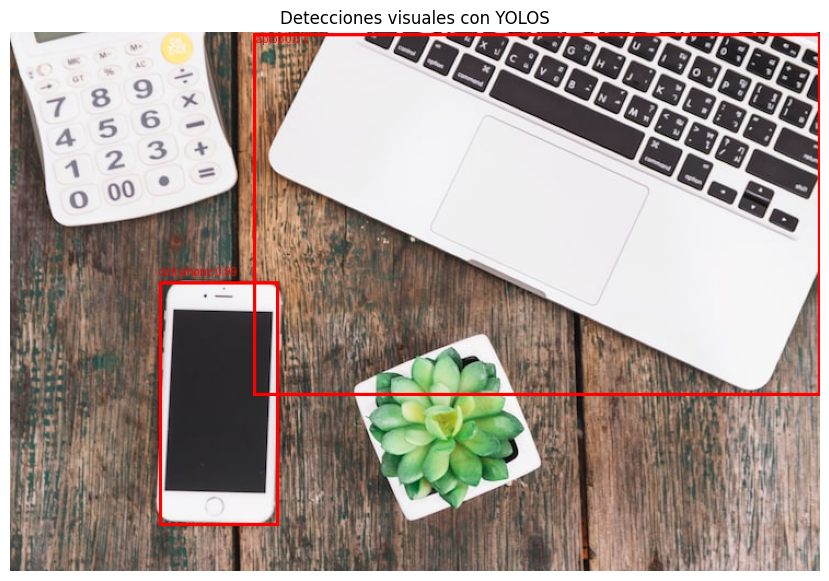

In [19]:
def dibujar_detecciones(image, detecciones, score_min=0.3):
    img = image.copy()
    draw = ImageDraw.Draw(img)

    for det in detecciones:
        if det["score"] < score_min:
            continue

        box = det["box"]
        label = det["label"]
        score = det["score"]

        x1, y1, x2, y2 = box["xmin"], box["ymin"], box["xmax"], box["ymax"]

        draw.rectangle([x1, y1, x2, y2], outline="red", width=3)
        draw.text((x1, max(0, y1 - 15)), f"{label} {score:.2f}", fill="red")

    return img

img_det = dibujar_detecciones(image, detecciones, score_min=0.2)

plt.figure(figsize=(12, 7))
plt.imshow(img_det)
plt.axis("off")
plt.title("Detecciones visuales con YOLOS")
plt.show()

# Parte C — Caso combinado: texto + visión para scoring auditor

In [20]:
def scoring_auditoria(texto_alerta, image=None):
    pred, ranking = clasificar_alerta(texto_alerta)
    confianza_texto = float(ranking.iloc[0]["probabilidad"])

    riesgo_base = mapa_riesgo[pred]

    num_detecciones = 0
    if image is not None:
        dets = object_detector(image)
        num_detecciones = sum(1 for d in dets if d["score"] >= 0.3)

    puntos = 0

    if riesgo_base == "ALTO":
        puntos += 70
    elif riesgo_base == "MEDIO-ALTO":
        puntos += 50
    else:
        puntos += 20

    if confianza_texto >= 0.70:
        puntos += 15
    elif confianza_texto >= 0.50:
        puntos += 10
    else:
        puntos += 5

    if num_detecciones > 0:
        puntos += 5

    if puntos >= 80:
        prioridad = "P1 - Revisión inmediata"
    elif puntos >= 60:
        prioridad = "P2 - Revisión prioritaria"
    elif puntos >= 40:
        prioridad = "P3 - Revisión ordinaria"
    else:
        prioridad = "P4 - Bajo riesgo"

    return {
        "texto_alerta": texto_alerta,
        "categoria_textual": pred,
        "riesgo_base": riesgo_base,
        "confianza_texto": round(confianza_texto, 4),
        "detecciones_visuales": num_detecciones,
        "score_auditoria": puntos,
        "prioridad": prioridad
    }

caso_demo = "Transferencia elevada a beneficiario nuevo en país de riesgo tras cambio reciente de IBAN."

resultado_demo = scoring_auditoria(caso_demo, image=image)
pd.DataFrame([resultado_demo])

,texto_alerta,categoria_textual,riesgo_base,confianza_texto,detecciones_visuales,score_auditoria,prioridad
0,Transferencia elevada a beneficiario nuevo en ...,fraude_transferencia,ALTO,0.756,2,90,P1 - Revisión inmediata


# Parte D — Explicación para auditores

## Cómo explicarlo en una sesión

### 1. Qué hace BERT

BERT transforma lenguaje natural en vectores numéricos. En este caso, alertas como:

> "Correo urgente pide introducir claves en una web externa"

se convierten en una representación que permite clasificar el caso como `phishing`.

### 2. Qué hace YOLOS/YOLO-like

El modelo visual detecta objetos o regiones relevantes en una imagen. En banca podría usarse para analizar documentos escaneados, capturas de pantallas operativas, justificantes de transferencia, facturas y documentos KYC.

### 3. Qué no debe hacerse directamente

No se debe usar este notebook como sistema real de decisión automática. Para producción harían falta datos reales anonimizados, validación legal y de compliance, métricas por segmento, control de sesgos, trazabilidad, revisión humana, monitorización de drift y auditoría del modelo.

### 4. Valor para auditoría

El valor no está en reemplazar al auditor, sino en priorizar expedientes, detectar patrones anómalos, acelerar revisión documental, crear alertas explicables y reducir carga manual repetitiva.


# Parte E — Extensiones recomendadas

1. Sustituir el dataset sintético por casos anonimizados reales.
2. Entrenar un clasificador BERT específico con histórico de alertas.
3. Fine-tuning de YOLO/YOLOS con documentos bancarios etiquetados.
4. Añadir SHAP/LIME para explicación de texto.
5. Añadir reglas de negocio: país de riesgo, beneficiario nuevo, importe alto, horario anómalo, dispositivo nuevo y geolocalización inusual.
6. Crear dashboard con Streamlit para auditores.
